In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 1000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [ ]:
T_initial = 512
T_val = 100
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 1000000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
state_posencode_oh = position_encoder(states[:,0], type="onehot")
new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

unique_irewards = np.sort(np.unique(irewards))
print(unique_irewards)
# Build mapping: real value → class index
val_to_class = {val: idx for idx, val in enumerate(unique_irewards)}
class_to_val = {idx: val for idx, val in enumerate(unique_irewards)}  # inverse map

# Assign class indices
irewards_class = np.array([val_to_class[y] for y in irewards])

Y_class, counts = np.unique(irewards_class, return_counts=True)
priors = counts / counts.sum()
print(priors)

X_train = new_state_oh[:T_initial,:]
Y_train = irewards_class[:T_initial]

X_val = new_state_oh[T_initial:T_initial+T_val,:]
Y_val = irewards_class[T_initial:T_initial+T_val]
# print(Y_train)






[ 0.          0.10077696  0.1679616   0.279936    0.46656     0.7776
  1.296       2.16        3.6         6.         10.        ]
[0.857115 0.01439  0.014357 0.014239 0.014232 0.014206 0.014343 0.014171
 0.014299 0.01442  0.014228]


# PAFV - MLP - Classifier

In [152]:
T_initial = 1024
T_val = 100
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 1000000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
state_posencode_oh = position_encoder(states[:,0], type="onehot")
new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

unique_irewards = np.sort(np.unique(irewards))
print(unique_irewards)
# Build mapping: real value → class index
val_to_class = {val: idx for idx, val in enumerate(unique_irewards)}
class_to_val = {idx: val for idx, val in enumerate(unique_irewards)}  # inverse map

# Assign class indices
irewards_class = np.array([val_to_class[y] for y in irewards])

Y_class, counts = np.unique(irewards_class, return_counts=True)
priors = counts / counts.sum()
print(priors)

X_train = new_state_oh[:T_initial,:]
Y_train = irewards_class[:T_initial]

X_val = new_state_oh[T_initial:T_initial+T_val,:]
Y_val = irewards_class[T_initial:T_initial+T_val]
# print(Y_train)

batch_size_train = 32
batch_size_val = T_val
train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.int64)))
val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.int64)))
train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

[ 0.          0.10077696  0.1679616   0.279936    0.46656     0.7776
  1.296       2.16        3.6         6.         10.        ]
[0.857115 0.01439  0.014357 0.014239 0.014232 0.014206 0.014343 0.014171
 0.014299 0.01442  0.014228]


In [153]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), n_classes=11, p_dropout=0.2):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, n_classes)]  # logits (no softmax here)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x) 


def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = torch.nn.CrossEntropyLoss(weight=torch.from_numpy(priors.astype(np.float32)).to(device))

    best_val = -1
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            total_acc  += accuracy(logits.detach(), yb)
            n_batches  += 1

        # validation
        model.eval()
        val_acc = 0.0
        n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_acc += accuracy(logits, yb)
                n_val += 1
        val_acc /= max(1, n_val)

        tr_loss = total_loss / max(1, n_batches)
        tr_acc  = total_acc  / max(1, n_batches)
        print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} | train acc {tr_acc:.3f} | val acc {val_acc:.3f}")

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_proba(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        logits = model(torch.from_numpy(X).to(device).float())
        return logits.softmax(dim=1).cpu()  # (N, 11)

In [154]:
model = MLP(input_dim=X_train.shape[1], hidden=(256,128), n_classes=11, p_dropout=0.1)
model = train_model(model, train_loader, val_loader, epochs=300, lr=3e-4)

Epoch 01 | train loss 1.8077 | train acc 0.725 | val acc 0.910
Epoch 02 | train loss 0.4078 | train acc 0.868 | val acc 0.910
Epoch 03 | train loss 0.0587 | train acc 0.868 | val acc 0.910
Epoch 04 | train loss 0.0345 | train acc 0.868 | val acc 0.910
Epoch 05 | train loss 0.0288 | train acc 0.868 | val acc 0.910
Epoch 06 | train loss 0.0263 | train acc 0.868 | val acc 0.910
Epoch 07 | train loss 0.0247 | train acc 0.868 | val acc 0.910
Epoch 08 | train loss 0.0247 | train acc 0.868 | val acc 0.910
Epoch 09 | train loss 0.0242 | train acc 0.868 | val acc 0.910
Epoch 10 | train loss 0.0233 | train acc 0.868 | val acc 0.910
Epoch 11 | train loss 0.0235 | train acc 0.868 | val acc 0.910
Epoch 12 | train loss 0.0228 | train acc 0.868 | val acc 0.910
Epoch 13 | train loss 0.0226 | train acc 0.868 | val acc 0.910
Epoch 14 | train loss 0.0228 | train acc 0.868 | val acc 0.910
Epoch 15 | train loss 0.0222 | train acc 0.868 | val acc 0.910
Epoch 16 | train loss 0.0220 | train acc 0.868 | val ac

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/1658115315.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))


0.9065396087019804


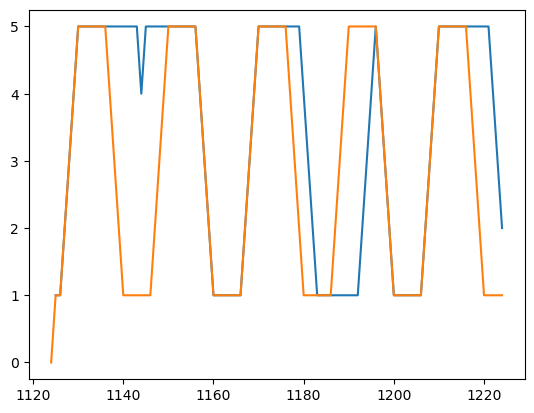

In [155]:
T = T_initial+T_val
gamma = 0.5
t_prime = 6
current_state = np.random.choice([int(i) for i in range(7)],size = 1)
future_states = [current_state.item()]
# print(current_state)
FUTURE_STATE = []
for delta_t in range(100):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        pred_prob = predict_proba(model, features)
        pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
        irewards_pred[:,i] = pred_val.reshape(-1)
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    # Extract rewards from second column onward (t=1 to t=T)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, t_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = int(df_all_paths.iloc[bext_idx,1])
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state

# print(T,future_states,len(future_states))
FUTURE_STATE.append(future_states)

irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
preward = compute_normalized_future_rewards(irewards_test,100,0.5)
path, ireward_opt = path_opt(future_states[0], T, 100)
preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
print(pregret)
plt.plot(np.arange(T+1,T+101),future_states[1:])
plt.plot(np.arange(T,T+101),path)
plt.show()

[ 0.          0.10077696  0.1679616   0.279936    0.46656     0.7776
  1.296       2.16        3.6         6.         10.        ]
(3687, 57) (3687,) (409, 57) (409, 57)
Epoch 01 | train loss 1.5953 | train acc 0.750 | val acc 0.895
Epoch 02 | train loss 0.0834 | train acc 0.858 | val acc 0.895
Epoch 03 | train loss 0.0294 | train acc 0.858 | val acc 0.895
Epoch 04 | train loss 0.0273 | train acc 0.858 | val acc 0.895
Epoch 05 | train loss 0.0267 | train acc 0.858 | val acc 0.895
Epoch 06 | train loss 0.0265 | train acc 0.857 | val acc 0.895
Epoch 07 | train loss 0.0264 | train acc 0.857 | val acc 0.895
Epoch 08 | train loss 0.0259 | train acc 0.858 | val acc 0.895
Epoch 09 | train loss 0.0257 | train acc 0.858 | val acc 0.895
Epoch 10 | train loss 0.0253 | train acc 0.858 | val acc 0.895
Epoch 11 | train loss 0.0252 | train acc 0.857 | val acc 0.895
Epoch 12 | train loss 0.0249 | train acc 0.858 | val acc 0.895
Epoch 13 | train loss 0.0249 | train acc 0.857 | val acc 0.895
Epoch 14 | 

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/2323851762.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_11586/2323851762.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


2.420732626866877


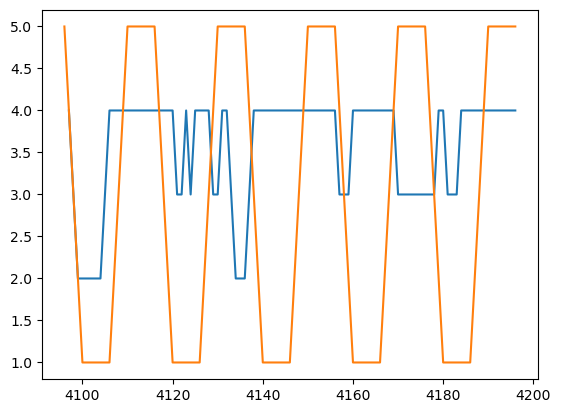

In [ ]:
### MLP Classifier
DELTA_t = 5
t_prime = 6
batch_size_train = 32
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048,4096]
Ts = [4096]
for rep in range(1):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

    unique_irewards = np.sort(np.unique(irewards))
    print(unique_irewards)
    # Build mapping: real value → class index
    val_to_class = {val: idx for idx, val in enumerate(unique_irewards)}
    class_to_val = {idx: val for idx, val in enumerate(unique_irewards)}  # inverse map

    # Assign class indices
    irewards_class = np.array([val_to_class[y] for y in irewards])

    Y_class, counts = np.unique(irewards_class, return_counts=True)
    priors = counts / counts.sum()
    print(priors)
    for T in Ts:
        T_val = int(0.1*T)
        T_initial = T - T_val

        X_train = new_state_oh[:T_initial,:]
        Y_train = irewards_class[:T_initial]

        X_val = new_state_oh[T_initial:T_initial+T_val,:]
        Y_val = irewards_class[T_initial:T_initial+T_val]
        print(X_train.shape,Y_train.shape,X_val.shape,X_val.shape)
        if T >= 1024:
            batch_size_train = 64
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.int64)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.int64)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model = MLP(input_dim=X_train.shape[1],  hidden=(256,128), n_classes=11, p_dropout=0.1)
        model = train_model(model, train_loader, val_loader, epochs=500, lr=1e-4)

        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_prob = predict_proba(model, features)
                pred_val = np.dot(pred_prob,unique_irewards.reshape(-1,1))
                irewards_pred[:,i] = pred_val.reshape(-1)
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
        
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/NN_Yuxin/NNClassfier_oh_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )


# PAFM - Regressor - MLP

In [64]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden=(256, 128), p_dropout=0.2, use_sigmoid=True):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        if use_sigmoid:           # keep preds in [0,1] if y is normalized
            layers += [nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)        # (N, 1)

def mse_loss(pred, target, eps=1e-12):
    # return torch.sqrt(nn.functional.mse_loss(pred, target) + eps)
    return nn.functional.mse_loss(pred, target)

def train_regressor(model, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-4, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_tr = float("inf")
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tot_rmse, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb = xb.to(device).float()
            yb = yb.to(device).float().view(-1, 1)  # ensure (N,1)

            opt.zero_grad()
            preds = model(xb)
            loss = mse_loss(preds, yb)
            loss.backward()
            opt.step()

            tot_rmse += loss.item()
            n_batches += 1

        # validation
        model.eval()
        val_rmse, m = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device).float()
                yb = yb.to(device).float().view(-1, 1)
                preds = model(xb)
                val_rmse += mse_loss(preds, yb).item()
                m += 1
        val_rmse /= max(1, m)
        tr_rmse = tot_rmse / max(1, n_batches)
        if ep % 100 == 0:
            print(f"Epoch {ep:02d} | train MSE {tr_rmse:.6f} | val MSE {val_rmse:.6f}")

        if tr_rmse <= best_tr:
            if val_rmse <= best_val: ## Ignore the posibility of overfitting
                best_tr = tr_rmse
                best_val = val_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                print(f"Best Model: Epoch {ep:02d} | train MSE {tr_rmse:.6f} | val MSE {val_rmse:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        if isinstance(X, torch.Tensor):
            X_t = X.to(device).float()
        else:
            X_t = torch.from_numpy(np.asarray(X, dtype=np.float32)).to(device)
        preds = model(X_t).cpu().squeeze(1)
    return preds

In [107]:
T_initial = 2500
T_val = 100
X_train = new_state_oh[:T_initial,:]
Y_train = np.array(irewards[:T_initial]).reshape(-1,1)/10

X_val = new_state_oh[T_initial:T_initial+T_val,:]
Y_val = np.array(irewards[T_initial:T_initial+T_val]).reshape(-1,1)/10
print(X_train.shape,Y_train.shape)

(2500, 57) (2500, 1)


In [ ]:
DELTA_t = 5
t_prime = 6
batch_size_train = 32
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
for rep in range(10):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T in Ts:
        n_seq = int((T+100)/(DELTA_t+1))
        # n_seq = T
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards,gamma = 0.5))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe)
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
        print(STATES_arr.shape,REWARDS_arr.shape)
        X = STATES_arr
        Y = REWARDS_arr
        X_train = X[:T,:]
        Y_train = np.array(Y[:T]).reshape(-1,1)/10

        X_val = X[T:,:]
        Y_val = np.array(Y[T:]).reshape(-1,1)/10
        print(X_train.shape,Y_train.shape,X_val.shape,X_val.shape)

        
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model = MLPRegressor(input_dim=X_train.shape[1], hidden=(512,256), p_dropout=0.1, use_sigmoid=True)
        model = train_regressor(model, train_loader, val_loader, epochs=500, lr=1e-4,weight_decay = 1e-4)

        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = predict(model, features)*10
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
        
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/NN_optimal_oh_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )


# PAFM - MLP - Sim

(180, 57) (180,) (20, 57) (20, 57)
Best Model: Epoch 01 | train MSE 3.862026 | val MSE 0.242829
Best Model: Epoch 40 | train MSE 0.115682 | val MSE 0.193307
Epoch 100 | train MSE 0.135473 | val MSE 0.441682
Epoch 200 | train MSE 0.118784 | val MSE 0.350263
Epoch 300 | train MSE 0.172506 | val MSE 0.422829
Best Model: Epoch 319 | train MSE 0.115060 | val MSE 0.169950
Best Model: Epoch 325 | train MSE 0.109162 | val MSE 0.147674
Best Model: Epoch 342 | train MSE 0.104160 | val MSE 0.136157
Best Model: Epoch 345 | train MSE 0.076945 | val MSE 0.130159
Best Model: Epoch 349 | train MSE 0.062086 | val MSE 0.103665
Epoch 400 | train MSE 0.143498 | val MSE 0.345845
Epoch 500 | train MSE 0.118094 | val MSE 0.283193
Epoch 600 | train MSE 0.145772 | val MSE 0.127345
Epoch 700 | train MSE 0.165614 | val MSE 0.162487
Epoch 800 | train MSE 0.118668 | val MSE 0.205845
Epoch 900 | train MSE 0.218401 | val MSE 0.162475
Best Model: Epoch 987 | train MSE 0.045110 | val MSE 0.077839
Best Model: Epoch 995

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_50692/3772849894.py:48: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  irewards_pred[:,i] = predict(model, features)
/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_50692/3772849894.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.268345269340888


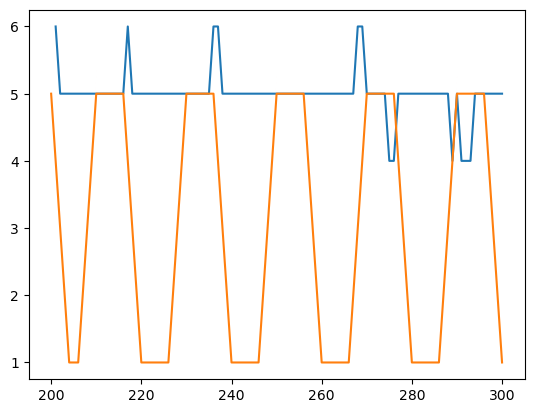

(360, 57) (360,) (40, 57) (40, 57)
Best Model: Epoch 01 | train MSE 2.758967 | val MSE 3.550912
Best Model: Epoch 02 | train MSE 2.324373 | val MSE 3.544977
Best Model: Epoch 03 | train MSE 1.720805 | val MSE 3.134608
Best Model: Epoch 04 | train MSE 1.346416 | val MSE 2.709733
Best Model: Epoch 06 | train MSE 0.431175 | val MSE 1.747131
Best Model: Epoch 14 | train MSE 0.238443 | val MSE 1.707732
Best Model: Epoch 28 | train MSE 0.123833 | val MSE 1.659622
Best Model: Epoch 33 | train MSE 0.091654 | val MSE 1.625302
Epoch 100 | train MSE 0.181180 | val MSE 1.963375
Best Model: Epoch 155 | train MSE 0.087336 | val MSE 1.525266
Epoch 200 | train MSE 0.108330 | val MSE 2.111856
Best Model: Epoch 222 | train MSE 0.061396 | val MSE 1.511232
Best Model: Epoch 223 | train MSE 0.059947 | val MSE 1.445662
Best Model: Epoch 277 | train MSE 0.030215 | val MSE 1.143275
Epoch 300 | train MSE 0.087765 | val MSE 1.295538
Epoch 400 | train MSE 0.164575 | val MSE 1.292157
Epoch 500 | train MSE 0.08579

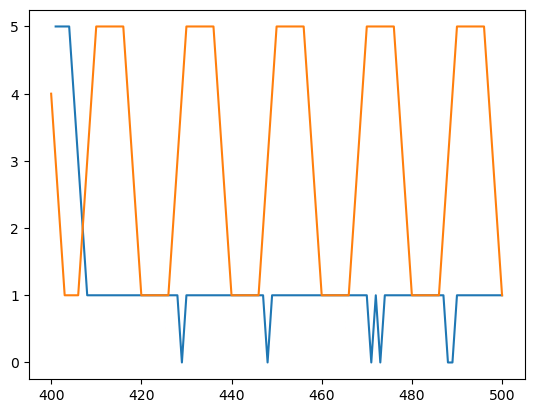

In [71]:
t_prime = 6
batch_size_train = 32
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048,4096]
Ts = [200,400]
# Ts = [750,1024,1250,1500]
for rep in range(1):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        # T_val = 1## Ignore Validating
        T_val = int(0.1*T)
        T_initial = T - T_val

        X_train = new_state_oh[:T_initial,:]
        Y_train = irewards[:T_initial]

        X_val = new_state_oh[T_initial:T,:]
        Y_val = np.array(irewards[T_initial:T]).reshape(-1,1)
        print(X_train.shape,Y_train.shape,X_val.shape,X_val.shape)
        if T >= 1024:
            batch_size_train = 64
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model = MLPRegressor(input_dim=X_train.shape[1], hidden=(32,32), p_dropout=0.1, use_sigmoid=False)
        model = train_regressor(model, train_loader, val_loader, epochs=1500, lr=1e-2,weight_decay = 1e-4)

        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = predict(model, features)
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
        
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5,normalization=True)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization=True)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    # np.savez(
    #     f"../results/PAFM/NN_Yuxin/NN_oh_wo_normy_woval_dropout0.1_w_time128_4096_lookahead{t_prime}_reps{rep}.npz",
    #     future_states =FUTURE_STATE_arr
    #     )


# PVFM - MLP - Regressor

In [ ]:
DELTA_t = 10
t_prime = 6
# Ts = [1000,5000,10000,20000,40000,80000]
Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(1):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T_initial in Ts:
        # n_seq = int(T/(DELTA_t+1))
        T_val = int(T_initial*0.2)
        T= T_val + T_initial
        n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(5000)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe[0,:])
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
        # print(STATES_arr.shape,REWARDS_arr.shape)
        # print(REWARDS_arr[:3],REWARDS_arr[-3:]
        
        X_train = STATES_arr[:T_initial,:]
        Y_train = np.array(REWARDS_arr[:T_initial]).reshape(-1,1)/ 10

        X_val = STATES_arr[T_initial:T,:]
        Y_val = np.array(REWARDS_arr[T_initial:T]).reshape(-1,1)/ 10
        print(X_train.shape,Y_train.shape,X_val.shape,Y_val.shape)
        epochs = 200
        weight_decay = 1e-6
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T_initial <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            # epochs = 100
            hidden_layers = (192,128)
        elif T_initial == 10000:
            # learning_rate = 3e-4
            batch_size_train = 128
            hidden_layers = (512,256)
        elif T_initial == 20000:
            # learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 40000:
            # learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 80000:
            # learning_rate = 1e-4
            batch_size_train = 256
            # hidden_layers = (1024,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T_initial+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T_initial+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*10
                prewards_pred[:,i] = pred_val
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T_initial+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T_initial+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T_initial, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T_initial+1,T_initial+101),future_states[1:])
        plt.plot(np.arange(T_initial,T_initial+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    # np.savez(
    #     f"../results/PVFM/NN_Yuxin/NN_SameStructure_optimal_oh_w_time1000_80000_w_lookahead{t_prime}_reps{rep}.npz",
    #     future_states =FUTURE_STATE_arr
    #     )



In [ ]:
DELTA_t = 10
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in range(10):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T_initial in Ts:
        # n_seq = int(T/(DELTA_t+1))
        T_val = int(T_initial*0.2)
        T= T_val + T_initial
        n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T_initial-DELTA_t)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe[0,:])
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
        # print(STATES_arr.shape,REWARDS_arr.shape)
        # print(REWARDS_arr[:3],REWARDS_arr[-3:]
        
        X_train = STATES_arr[:T_initial,:]
        Y_train = np.array(REWARDS_arr[:T_initial]).reshape(-1,1)/ 10

        X_val = STATES_arr[T_initial:T,:]
        Y_val = np.array(REWARDS_arr[T_initial:T]).reshape(-1,1)/ 10
        print(X_train.shape,Y_train.shape,X_val.shape,Y_val.shape)
        
        epochs = 500
        weight_decay = 1e-6
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T_initial <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            epochs = 500
            # hidden_layers = (192,128)
        elif T_initial == 10000:
            learning_rate = 3e-4
            batch_size_train = 128
            # hidden_layers = (512,256)
        elif T_initial == 20000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 40000:
            learning_rate = 3e-4
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T_initial == 80000:
            learning_rate = 3e-4
            batch_size_train = 256
            hidden_layers = (512,256,128)
            # epochs = 50
        elif T_initial <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T_initial <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T_initial <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        
        batch_size_val = T_val
        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T_initial+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T_initial+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*10
                prewards_pred[:,i] = pred_val
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T_initial+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T_initial+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T_initial, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T_initial+1,T_initial+101),future_states[1:])
        plt.plot(np.arange(T_initial,T_initial+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/NN_Yuxin/NN_SameStructure_optimal_oh_w_time1000_80000_w_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



training timestamps 1000
(900, 57) (900, 1)
Best Model: Epoch 01 | train MSE 0.187131 | val MSE 0.156505
Best Model: Epoch 02 | train MSE 0.102085 | val MSE 0.105876
Best Model: Epoch 03 | train MSE 0.073492 | val MSE 0.105739
Best Model: Epoch 04 | train MSE 0.070852 | val MSE 0.105510
Best Model: Epoch 07 | train MSE 0.065702 | val MSE 0.102986
Best Model: Epoch 09 | train MSE 0.060720 | val MSE 0.102415
Best Model: Epoch 10 | train MSE 0.058033 | val MSE 0.102296
Epoch 100 | train MSE 0.012109 | val MSE 0.113940
Epoch 200 | train MSE 0.009403 | val MSE 0.112282
Epoch 300 | train MSE 0.008869 | val MSE 0.111054
Epoch 400 | train MSE 0.008455 | val MSE 0.111140
Epoch 500 | train MSE 0.008271 | val MSE 0.112120
900 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_50692/3731542037.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prewards_pred[:,i] = pred_val


1.160251504995752


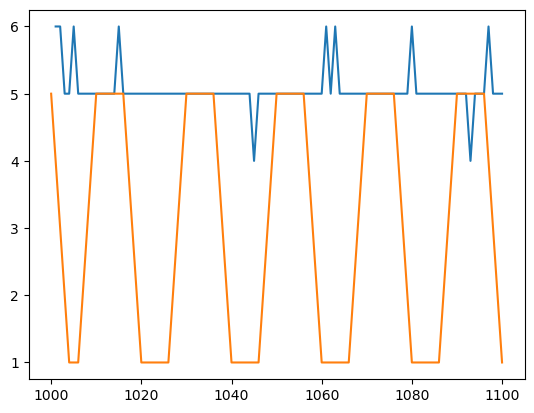

training timestamps 5000
(4500, 57) (4500, 1)
Best Model: Epoch 01 | train MSE 0.106842 | val MSE 0.065647
Best Model: Epoch 02 | train MSE 0.072951 | val MSE 0.065138
Best Model: Epoch 03 | train MSE 0.069927 | val MSE 0.064475
Best Model: Epoch 04 | train MSE 0.065874 | val MSE 0.064475
Epoch 100 | train MSE 0.010967 | val MSE 0.066785
Best Model: Epoch 108 | train MSE 0.010745 | val MSE 0.064319
Best Model: Epoch 137 | train MSE 0.009672 | val MSE 0.064033
Epoch 200 | train MSE 0.008848 | val MSE 0.068691
Epoch 300 | train MSE 0.008328 | val MSE 0.068089
Epoch 400 | train MSE 0.008164 | val MSE 0.070269
Epoch 500 | train MSE 0.008044 | val MSE 0.069543
4500 train done
2.3255133943886896


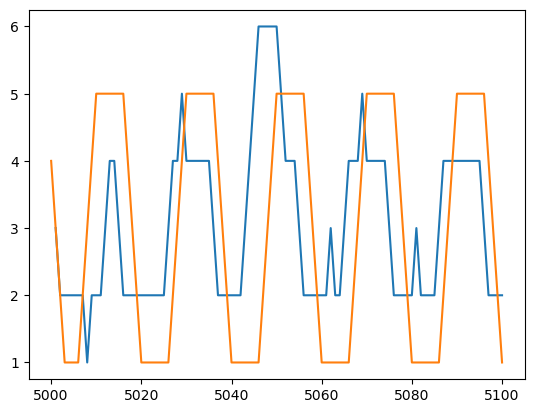

training timestamps 10000
(9000, 57) (9000, 1)
Best Model: Epoch 01 | train MSE 0.080635 | val MSE 0.093432
Best Model: Epoch 02 | train MSE 0.079312 | val MSE 0.093432
Best Model: Epoch 04 | train MSE 0.079297 | val MSE 0.093432
Best Model: Epoch 05 | train MSE 0.079272 | val MSE 0.093432
Best Model: Epoch 13 | train MSE 0.079258 | val MSE 0.093432
Epoch 100 | train MSE 0.079576 | val MSE 0.093432
Epoch 200 | train MSE 0.079760 | val MSE 0.093432
Epoch 300 | train MSE 0.079335 | val MSE 0.093432
Best Model: Epoch 341 | train MSE 0.079258 | val MSE 0.093432
Best Model: Epoch 385 | train MSE 0.079258 | val MSE 0.093432
Epoch 400 | train MSE 0.079276 | val MSE 0.093432
Epoch 500 | train MSE 0.079372 | val MSE 0.093432
Best Model: Epoch 563 | train MSE 0.079257 | val MSE 0.093432
Epoch 600 | train MSE 0.079533 | val MSE 0.093432
9000 train done
2.4051798883886897


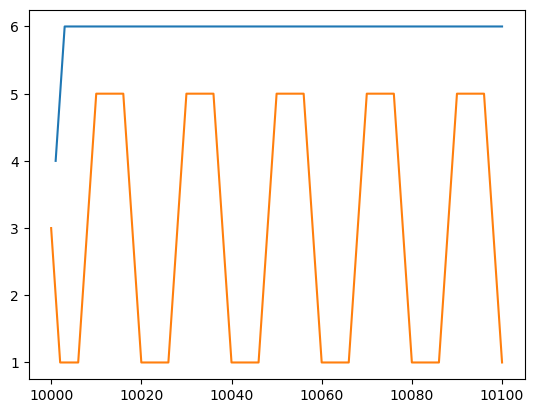

training timestamps 20000
(18000, 57) (18000, 1)
Best Model: Epoch 01 | train MSE 0.080162 | val MSE 0.091518
Best Model: Epoch 02 | train MSE 0.078180 | val MSE 0.091518
Best Model: Epoch 03 | train MSE 0.077167 | val MSE 0.091518
Best Model: Epoch 04 | train MSE 0.077102 | val MSE 0.091518
Best Model: Epoch 06 | train MSE 0.076812 | val MSE 0.091518
Best Model: Epoch 16 | train MSE 0.076624 | val MSE 0.091518
Best Model: Epoch 21 | train MSE 0.076597 | val MSE 0.091518
Best Model: Epoch 59 | train MSE 0.074689 | val MSE 0.082536
Best Model: Epoch 60 | train MSE 0.067832 | val MSE 0.074896
Best Model: Epoch 61 | train MSE 0.061053 | val MSE 0.072124
Epoch 100 | train MSE 0.043165 | val MSE 0.080253
Best Model: Epoch 119 | train MSE 0.032710 | val MSE 0.068316
Best Model: Epoch 122 | train MSE 0.024120 | val MSE 0.066949
Epoch 200 | train MSE 0.009949 | val MSE 0.075487
Epoch 300 | train MSE 0.008980 | val MSE 0.077132
Epoch 400 | train MSE 0.008305 | val MSE 0.081644
Epoch 500 | train

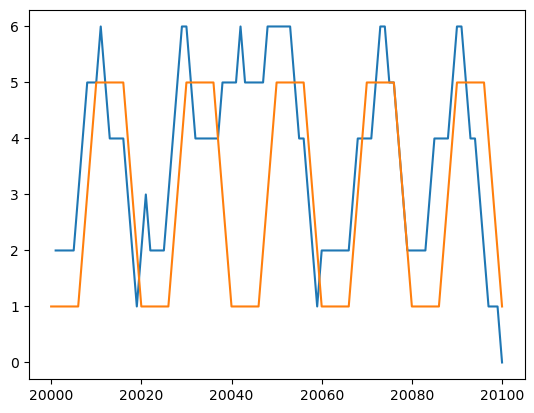

training timestamps 40000
(36000, 57) (36000, 1)
Best Model: Epoch 01 | train MSE 0.077943 | val MSE 0.080722
Best Model: Epoch 02 | train MSE 0.075001 | val MSE 0.080722
Best Model: Epoch 04 | train MSE 0.074715 | val MSE 0.080722
Best Model: Epoch 19 | train MSE 0.074630 | val MSE 0.080722
Best Model: Epoch 28 | train MSE 0.074584 | val MSE 0.080722
Best Model: Epoch 70 | train MSE 0.074460 | val MSE 0.080722
Epoch 100 | train MSE 0.075113 | val MSE 0.080722
Best Model: Epoch 155 | train MSE 0.074455 | val MSE 0.079998
Best Model: Epoch 157 | train MSE 0.070785 | val MSE 0.076361
Best Model: Epoch 158 | train MSE 0.063197 | val MSE 0.068710
Epoch 200 | train MSE 0.043986 | val MSE 0.073276
Best Model: Epoch 245 | train MSE 0.035832 | val MSE 0.057790
Best Model: Epoch 246 | train MSE 0.030241 | val MSE 0.054498
Best Model: Epoch 247 | train MSE 0.029120 | val MSE 0.053472
Epoch 300 | train MSE 0.012026 | val MSE 0.060918
Epoch 400 | train MSE 0.010035 | val MSE 0.055722
Epoch 500 | t

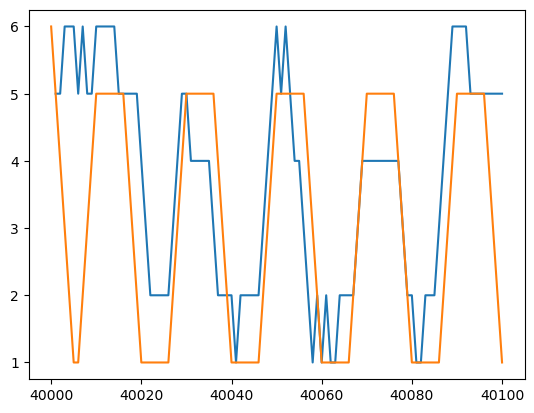

training timestamps 80000
(72000, 57) (72000, 1)
Best Model: Epoch 01 | train MSE 0.078988 | val MSE 0.073027
Best Model: Epoch 02 | train MSE 0.076147 | val MSE 0.073027
Best Model: Epoch 03 | train MSE 0.075685 | val MSE 0.073027
Best Model: Epoch 06 | train MSE 0.075662 | val MSE 0.073027
Best Model: Epoch 10 | train MSE 0.075649 | val MSE 0.073027
Best Model: Epoch 12 | train MSE 0.075563 | val MSE 0.073027
Best Model: Epoch 65 | train MSE 0.062380 | val MSE 0.045620
Best Model: Epoch 66 | train MSE 0.044578 | val MSE 0.044838
Best Model: Epoch 67 | train MSE 0.042496 | val MSE 0.044455
Epoch 100 | train MSE 0.016621 | val MSE 0.059159
Epoch 200 | train MSE 0.011596 | val MSE 0.060438
Epoch 300 | train MSE 0.010548 | val MSE 0.060659
Epoch 400 | train MSE 0.009991 | val MSE 0.061603
Epoch 500 | train MSE 0.009684 | val MSE 0.062063
Epoch 600 | train MSE 0.009388 | val MSE 0.059797
72000 train done
1.3280448838993997


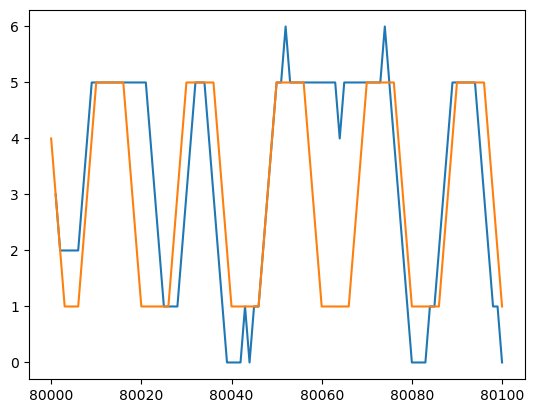

training timestamps 1000
(900, 57) (900, 1)
Best Model: Epoch 01 | train MSE 0.187090 | val MSE 0.131289
Best Model: Epoch 02 | train MSE 0.115174 | val MSE 0.066825
Best Model: Epoch 03 | train MSE 0.084107 | val MSE 0.058925
Best Model: Epoch 04 | train MSE 0.082129 | val MSE 0.058049
Best Model: Epoch 05 | train MSE 0.080864 | val MSE 0.057108
Best Model: Epoch 06 | train MSE 0.079317 | val MSE 0.056226
Best Model: Epoch 07 | train MSE 0.078208 | val MSE 0.055228
Best Model: Epoch 08 | train MSE 0.075659 | val MSE 0.054190
Best Model: Epoch 09 | train MSE 0.074444 | val MSE 0.053064
Best Model: Epoch 10 | train MSE 0.072745 | val MSE 0.051828
Best Model: Epoch 11 | train MSE 0.069782 | val MSE 0.050317
Best Model: Epoch 12 | train MSE 0.068109 | val MSE 0.048773
Best Model: Epoch 13 | train MSE 0.066747 | val MSE 0.047156
Best Model: Epoch 14 | train MSE 0.064593 | val MSE 0.045987
Best Model: Epoch 15 | train MSE 0.059434 | val MSE 0.043919
Best Model: Epoch 17 | train MSE 0.052689

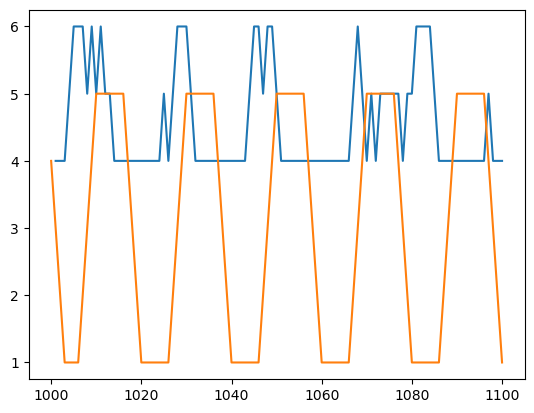

training timestamps 5000
(4500, 57) (4500, 1)
Best Model: Epoch 01 | train MSE 0.105903 | val MSE 0.063768
Best Model: Epoch 02 | train MSE 0.073724 | val MSE 0.062362
Best Model: Epoch 03 | train MSE 0.070579 | val MSE 0.061079
Best Model: Epoch 04 | train MSE 0.067903 | val MSE 0.060283
Epoch 100 | train MSE 0.010502 | val MSE 0.065300
Best Model: Epoch 149 | train MSE 0.009446 | val MSE 0.060031
Best Model: Epoch 190 | train MSE 0.008886 | val MSE 0.060029
Epoch 200 | train MSE 0.008618 | val MSE 0.059811
Best Model: Epoch 200 | train MSE 0.008618 | val MSE 0.059811
Best Model: Epoch 217 | train MSE 0.008574 | val MSE 0.059545
Best Model: Epoch 220 | train MSE 0.008569 | val MSE 0.059355
Best Model: Epoch 225 | train MSE 0.008534 | val MSE 0.059322
Best Model: Epoch 228 | train MSE 0.008501 | val MSE 0.058498
Epoch 300 | train MSE 0.008198 | val MSE 0.059593
Epoch 400 | train MSE 0.008008 | val MSE 0.060796
Best Model: Epoch 417 | train MSE 0.007957 | val MSE 0.058261
Epoch 500 | tr

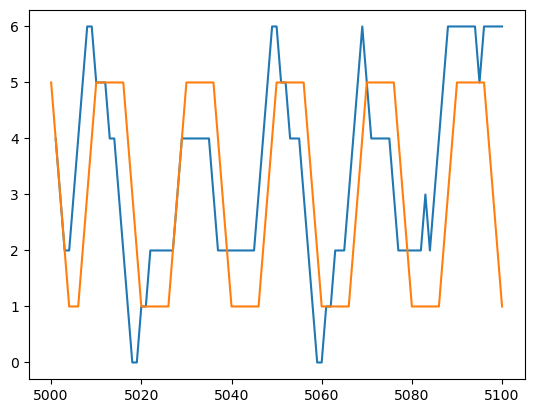

training timestamps 10000
(9000, 57) (9000, 1)
Best Model: Epoch 01 | train MSE 0.081552 | val MSE 0.095616
Best Model: Epoch 02 | train MSE 0.080387 | val MSE 0.095616
Best Model: Epoch 03 | train MSE 0.080325 | val MSE 0.095616
Best Model: Epoch 04 | train MSE 0.080146 | val MSE 0.095616
Best Model: Epoch 05 | train MSE 0.080137 | val MSE 0.095616
Best Model: Epoch 06 | train MSE 0.080083 | val MSE 0.095616
Best Model: Epoch 26 | train MSE 0.080083 | val MSE 0.095616
Best Model: Epoch 87 | train MSE 0.080081 | val MSE 0.095616
Epoch 100 | train MSE 0.080114 | val MSE 0.095616
Epoch 200 | train MSE 0.080113 | val MSE 0.095616
Best Model: Epoch 230 | train MSE 0.080081 | val MSE 0.095616
Epoch 300 | train MSE 0.080148 | val MSE 0.095616
Epoch 400 | train MSE 0.080096 | val MSE 0.095616
Best Model: Epoch 408 | train MSE 0.080079 | val MSE 0.095616
Epoch 500 | train MSE 0.080176 | val MSE 0.095616
Epoch 600 | train MSE 0.080304 | val MSE 0.095616
9000 train done
2.38717988838869


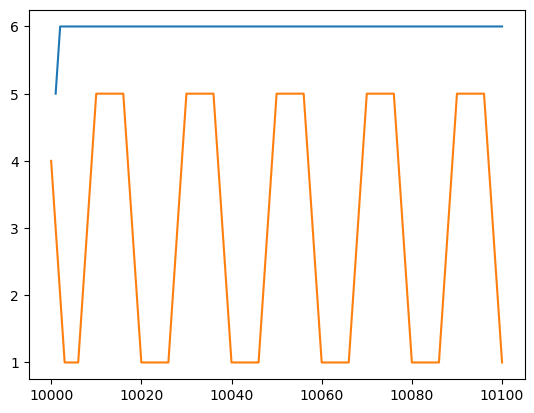

training timestamps 20000
(18000, 57) (18000, 1)
Best Model: Epoch 01 | train MSE 0.085377 | val MSE 0.086867
Best Model: Epoch 02 | train MSE 0.081769 | val MSE 0.086867
Best Model: Epoch 03 | train MSE 0.081215 | val MSE 0.086867
Best Model: Epoch 05 | train MSE 0.081076 | val MSE 0.086867
Best Model: Epoch 06 | train MSE 0.081026 | val MSE 0.086867
Best Model: Epoch 32 | train MSE 0.081000 | val MSE 0.086867
Best Model: Epoch 39 | train MSE 0.080893 | val MSE 0.086867
Best Model: Epoch 68 | train MSE 0.077596 | val MSE 0.073327
Best Model: Epoch 69 | train MSE 0.066024 | val MSE 0.063564
Epoch 100 | train MSE 0.043235 | val MSE 0.078171
Epoch 200 | train MSE 0.010832 | val MSE 0.067107
Best Model: Epoch 201 | train MSE 0.011253 | val MSE 0.062425
Epoch 300 | train MSE 0.009195 | val MSE 0.068256
Epoch 400 | train MSE 0.008570 | val MSE 0.067552
Epoch 500 | train MSE 0.008433 | val MSE 0.070711
Epoch 600 | train MSE 0.008234 | val MSE 0.068780
18000 train done
1.8066248363407396


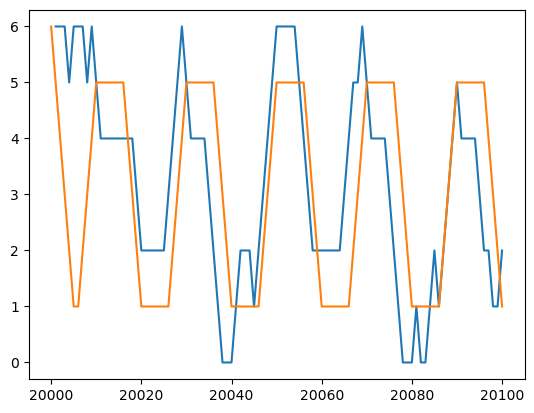

training timestamps 40000
(36000, 57) (36000, 1)
Best Model: Epoch 01 | train MSE 0.080873 | val MSE 0.063538
Best Model: Epoch 02 | train MSE 0.078542 | val MSE 0.063538
Best Model: Epoch 03 | train MSE 0.078413 | val MSE 0.063538
Best Model: Epoch 05 | train MSE 0.078401 | val MSE 0.063538
Best Model: Epoch 10 | train MSE 0.078144 | val MSE 0.063538
Best Model: Epoch 11 | train MSE 0.078115 | val MSE 0.063538
Best Model: Epoch 35 | train MSE 0.078113 | val MSE 0.063538
Best Model: Epoch 36 | train MSE 0.078059 | val MSE 0.063144
Best Model: Epoch 37 | train MSE 0.059267 | val MSE 0.040905
Epoch 100 | train MSE 0.011437 | val MSE 0.053092
Epoch 200 | train MSE 0.009639 | val MSE 0.052052
Epoch 300 | train MSE 0.009259 | val MSE 0.051798
Epoch 400 | train MSE 0.008851 | val MSE 0.051866
Epoch 500 | train MSE 0.008614 | val MSE 0.052247
Epoch 600 | train MSE 0.008394 | val MSE 0.051892
36000 train done
1.4246330823812665


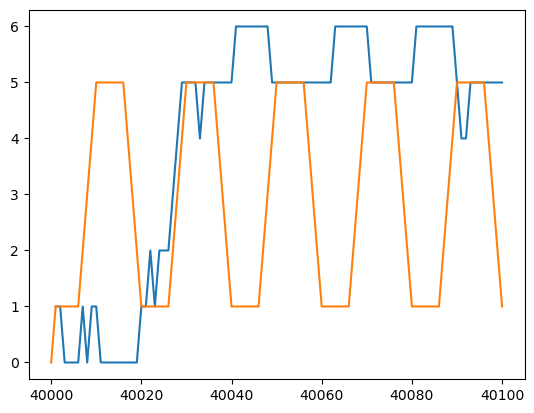

training timestamps 80000
(72000, 57) (72000, 1)
Best Model: Epoch 01 | train MSE 0.080139 | val MSE 0.085910
Best Model: Epoch 02 | train MSE 0.076038 | val MSE 0.085910
Epoch 100 | train MSE 0.076474 | val MSE 0.085910
Best Model: Epoch 135 | train MSE 0.075296 | val MSE 0.078833
Best Model: Epoch 136 | train MSE 0.064589 | val MSE 0.068866
Best Model: Epoch 137 | train MSE 0.058948 | val MSE 0.068047
Best Model: Epoch 176 | train MSE 0.034206 | val MSE 0.057718
Best Model: Epoch 177 | train MSE 0.028971 | val MSE 0.057313
Best Model: Epoch 182 | train MSE 0.025684 | val MSE 0.056787
Epoch 200 | train MSE 0.018706 | val MSE 0.063284
Epoch 300 | train MSE 0.012257 | val MSE 0.067445
Epoch 400 | train MSE 0.011181 | val MSE 0.067119
Epoch 500 | train MSE 0.010557 | val MSE 0.067891
Epoch 600 | train MSE 0.010138 | val MSE 0.068371
72000 train done
1.896201556416916


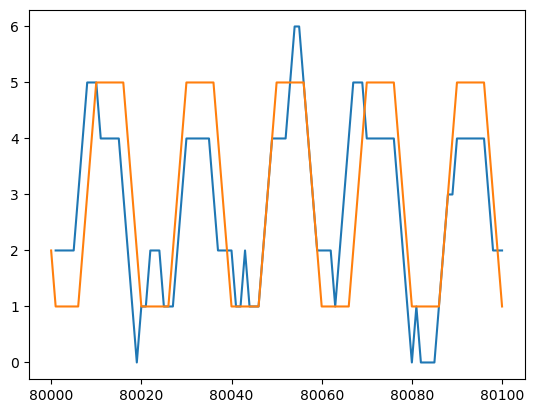

In [56]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [80000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
normalizer = 7 
for rep in np.arange(2):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        T_val = int(0.1*T)
        T_initial = T - T_val
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T,normalization=False)

        X_train = new_state_oh[:T_initial,:]
        Y_train = np.array(prewards[:T_initial]).reshape(-1,1)/ normalizer 

        X_val = new_state_oh[T_initial:T,:]
        Y_val = np.array(prewards[T_initial:T]).reshape(-1,1)/ normalizer
        print(X_train.shape,Y_train.shape)

        epochs = 600
        weight_decay = 1e-5
        learning_rate = 3e-4
        batch_size_train = 256
        hidden_layers = (512,256,128)
        if T <= 5000:
            learning_rate = 1e-4
            batch_size_train = 32
            epochs = 500
            # hidden_layers = (192,128)
        elif T == 10000:
            learning_rate = 3e-3
            batch_size_train = 64
            # hidden_layers = (512,256)
        elif T == 20000:
            learning_rate = 3e-3
            batch_size_train = 256
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T == 40000:
            learning_rate = 3e-3
            batch_size_train = 512
            # hidden_layers = (512,256,128)
            # epochs = 500
        elif T == 80000:
            learning_rate = 3e-3
            batch_size_train = 1024
            # hidden_layers = (512,256,128)
            # epochs = 50
        elif T <= 160000:
            learning_rate = 3e-3
            batch_size_train = 512
        elif T <= 320000:
            learning_rate = 1e-3
            batch_size_train = 1024
        elif T <= 640000:
            learning_rate = 1e-3
            batch_size_train = 2048
        
        batch_size_val = T_val

        train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(Y_train.astype(np.float32)))
        val_ds   = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(Y_val.astype(np.float32)))
        train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds,  batch_size=batch_size_val, shuffle=False, drop_last=False)

        model_reg = MLPRegressor(input_dim=X_train.shape[1], hidden=hidden_layers, p_dropout=0.2, use_sigmoid=True)
        model_reg = train_regressor(model_reg, train_loader, val_loader, epochs=epochs, lr=learning_rate,weight_decay = weight_decay)
        print(T_initial,'train done')
        
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                pred_val = predict(model_reg, features)*normalizer
                prewards_pred[:,i] = pred_val
            # idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma,normalization=True)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma,normalization=True)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/NN_Yuxin/NN_SameStructure_fixbug_oh_w_time1000_80000_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



In [49]:
max(prewards_pred[:,1])

np.float64(3.3726699352264404)